In [1]:
"""
Exploratory Data Analysis for bysykkel (3-timers data)
Plotter bruk over tid og mot værvariabler
"""

import pandas as pd
import matplotlib.pyplot as plt

C:\Users\jens.nilsen\python\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
DATA_FILE = "bysykkel_prophet_features_3h_weather.csv"

# --------------------------------------------------
# 1. LES DATA
# --------------------------------------------------

print("Leser data …")
df = pd.read_csv(DATA_FILE, parse_dates=["ds"])
df = df.sort_values("ds")
print("done!")

Leser data …
done!


In [5]:
# --------------------------------------------------
# 2. AGGREGER FOR OVERSIKT (DAG)
# --------------------------------------------------

df_daily = (
    df
    .set_index("ds")
    .resample("D")
    .agg({
        "y": "sum",
        "air_temperature": "mean",
        "wind_speed": "mean",
        "precipitation_amount": "sum"
    })
    .reset_index()
)


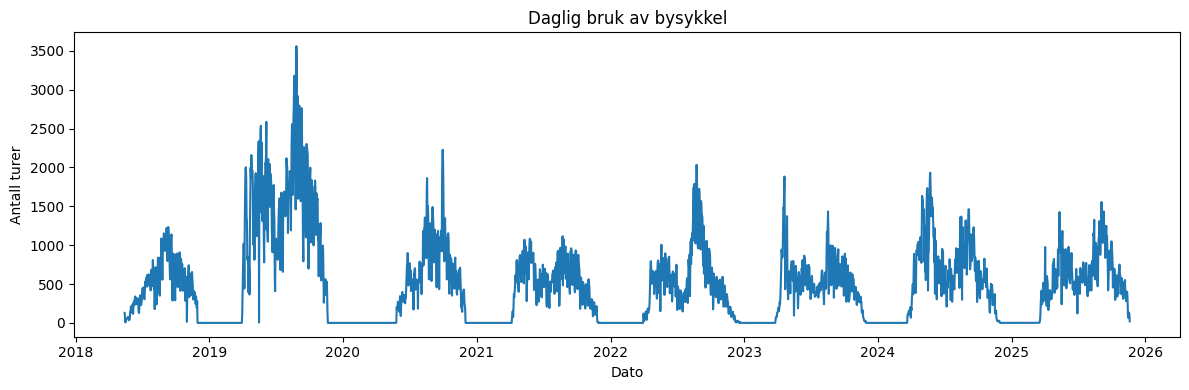

In [6]:
# --------------------------------------------------
# 3. TIDSERIE: BRUK OVER TID
# --------------------------------------------------

plt.figure(figsize=(12, 4))
plt.plot(df_daily["ds"], df_daily["y"])
plt.title("Daglig bruk av bysykkel")
plt.xlabel("Dato")
plt.ylabel("Antall turer")
plt.tight_layout()
plt.show()


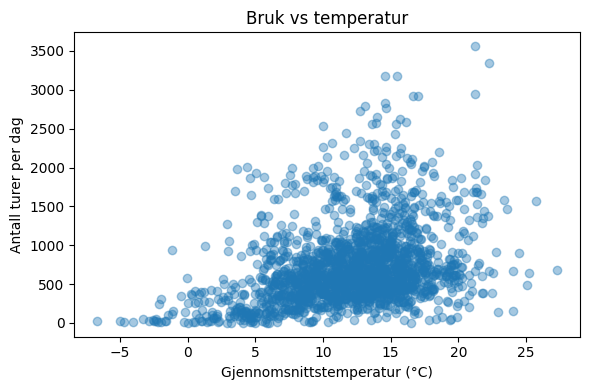

In [7]:

# --------------------------------------------------
# 4. BRUK VS TEMPERATUR
# --------------------------------------------------

plt.figure(figsize=(6, 4))
plt.scatter(
    df_daily["air_temperature"],
    df_daily["y"],
    alpha=0.4
)
plt.title("Bruk vs temperatur")
plt.xlabel("Gjennomsnittstemperatur (°C)")
plt.ylabel("Antall turer per dag")
plt.tight_layout()
plt.show()

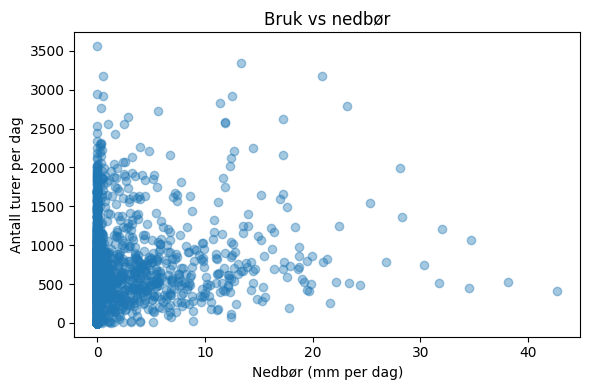

In [8]:
# --------------------------------------------------
# 5. BRUK VS NEDBØR
# --------------------------------------------------

plt.figure(figsize=(6, 4))
plt.scatter(
    df_daily["precipitation_amount"],
    df_daily["y"],
    alpha=0.4
)
plt.title("Bruk vs nedbør")
plt.xlabel("Nedbør (mm per dag)")
plt.ylabel("Antall turer per dag")
plt.tight_layout()
plt.show()

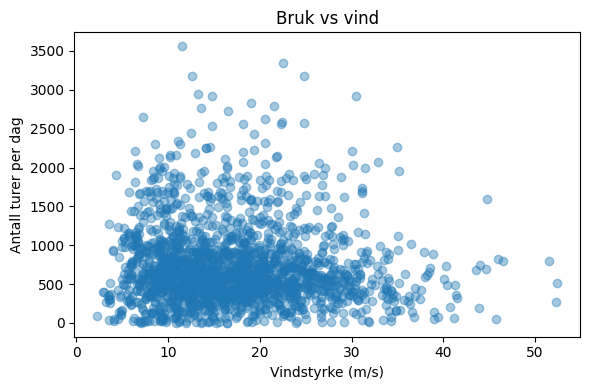

In [9]:
# --------------------------------------------------
# 6. BRUK VS VIND
# --------------------------------------------------

plt.figure(figsize=(6, 4))
plt.scatter(
    df_daily["wind_speed"],
    df_daily["y"],
    alpha=0.4
)
plt.title("Bruk vs vind")
plt.xlabel("Vindstyrke (m/s)")
plt.ylabel("Antall turer per dag")
plt.tight_layout()
plt.show()